<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-06-01 16:41:33--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  44.1MB/s    in 4.8s    

2026-06-01 16:41:38 (41.6 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 204.5 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 154.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 165.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 122.4 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [9]:
## Write your code here
## Write your code here
#Checking Column for values to get idea of the range
QUERY = """
SELECT DISTINCT CompTotal
FROM main
"""
pd.read_sql_query(QUERY, conn)
#resulted in a wide range - will have to sort data 

,CompTotal
0,NaN
1,2040000.0
2,28000.0
3,85000.0
4,50000.0
...,...
3333,3087958.0
3334,2520.0
3335,254600.0
3336,247433.0


In [10]:
QUERY = """
SELECT CompTotal
FROM main
ORDER BY CompTotal DESC
LIMIT 10
"""
pd.read_sql_query(QUERY, conn)

,CompTotal
0,1.000000e+150
1,1.000000e+65
2,1.000000e+53
3,1.000000e+44
4,8.000000e+27
5,1.000000e+20
6,1.111111e+15
7,3.040302e+14
8,7.587459e+13
9,7.777778e+12


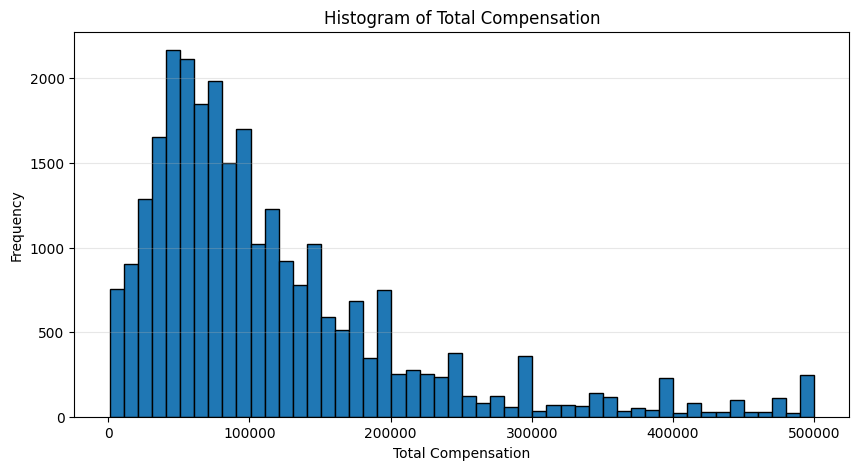

In [11]:
#Count NaN and check the range of values - for sensible value range
QUERY = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(CompTotal) AS non_null,
    COUNT(*) - COUNT(CompTotal) AS null_count,  
    MIN(CompTotal) AS min_value,
    MAX (CompTotal) AS max_value,
    AVG(CompTotal) AS Avg_Value
FROM main
"""

QUERY = """
SELECT  CompTotal
FROM main
WHERE CompTotal BETWEEN 1000 and 500000 AND CompTotal IS NOT NULL
"""
comp_df = pd.read_sql_query(QUERY, conn)


#Histogram
plt.figure(figsize=(10, 5))
plt.hist(comp_df['CompTotal'], bins=50, edgecolor='black')
plt.title('Histogram of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [12]:
## Write your code here
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


In [13]:
#Checking the columns
QUERY = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(YearsCodePro) AS non_null,
    COUNT(*) - COUNT(YearsCodePro) AS null_count,  
    MIN(YearsCodePro) AS min_value,
    MAX (YearsCodePro) AS max_value,
    AVG(YearsCodePro) AS Avg_Value
FROM main
LIMIT 10
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

#Results that the column is not completely numerical and needs to be cleaned before creating a Hist Plot

   total_rows  non_null  null_count min_value           max_value  Avg_Value
0       65437     51610       13827         1  More than 50 years  10.134935


In [14]:
#change to numerical
QUERY = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(YearsCodePro_cleaned) AS non_null,
    COUNT(*) - COUNT(YearsCodePro_cleaned) AS null_count,  
    MIN(YearsCodePro_cleaned) AS min_value,
    MAX (YearsCodePro_cleaned) AS max_value,
    AVG(YearsCodePro_cleaned) AS Avg_Value
FROM (
    SELECT 
        CASE
            WHEN YearsCodePro = 'more than 50 years' THEN 50
            WHEN YearsCodePro = 'less than 1 year' THEN 0
            ELSE CAST (YearsCodePro AS INT)
        END AS YearsCodePro_cleaned

FROM main
) t;
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

   total_rows  non_null  null_count  min_value  max_value  Avg_Value
0       65437     51610       13827          0         50  10.134935


In [15]:
#Cleaned Data with bins ready to create histogram
QUERY = """
SELECT
    FLOOR(YearsCodePro_cleaned / 5.0) * 5 AS bin_start,
    FLOOR(YearsCodePro_cleaned / 5.0) * 5 + 4 AS bin_end,
    COUNT(*) AS frequency
FROM (
    SELECT 
        CASE
            WHEN YearsCodePro = 'more than 50 years' THEN 50
            WHEN YearsCodePro = 'less than 1 year' THEN 0
            ELSE CAST(YearsCodePro AS INT)
        END AS YearsCodePro_cleaned
     FROM main
) t
WHERE YearsCodePro_cleaned IS NOT NULL
GROUP BY FLOOR(YearsCodePro_cleaned / 5.0) * 5
ORDER BY bin_start
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

    bin_start  bin_end  frequency
0         0.0      4.0      17021
1         5.0      9.0      12928
2        10.0     14.0       8549
3        15.0     19.0       4778
4        20.0     24.0       3501
5        25.0     29.0       2342
6        30.0     34.0       1290
7        35.0     39.0        696
8        40.0     44.0        379
9        45.0     49.0        112
10       50.0     54.0         14


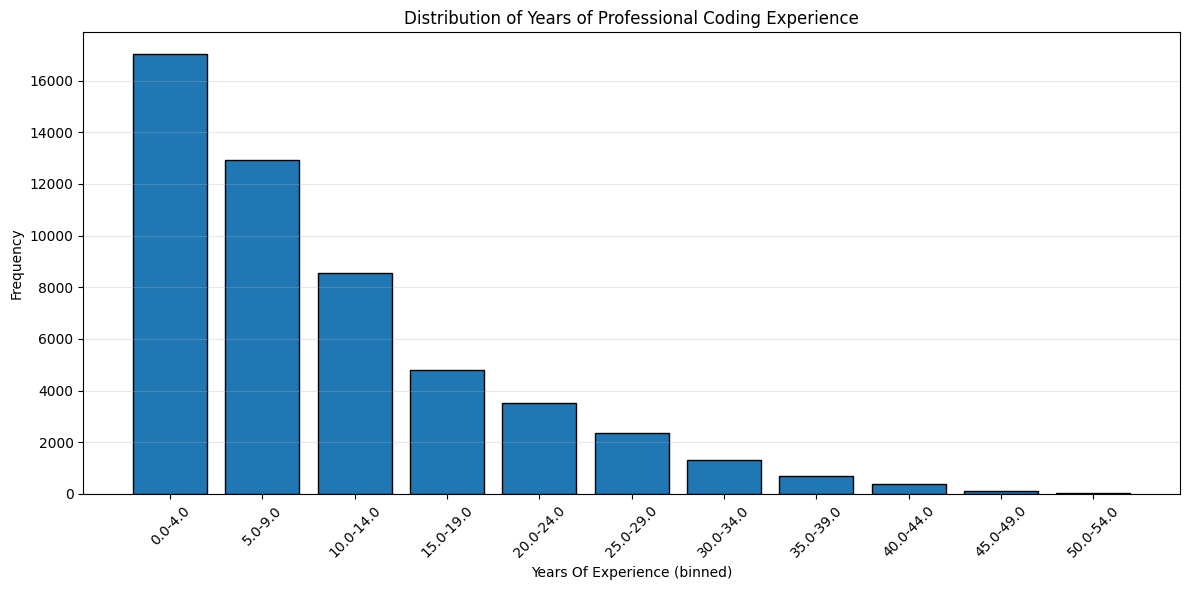

In [16]:
#plot have done a bar as already created bins and frequency
labels = df['bin_start'].astype(str) + '-' + df['bin_end'].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(labels, df['frequency'], edgecolor='black')
plt.title('Distribution of Years of Professional Coding Experience')
plt.xlabel('Years Of Experience (binned)')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [17]:
## Write your code here
QUERY = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(CompTotal) AS non_null,
    COUNT(*) - COUNT(CompTotal) AS null_count,  
    MIN(CompTotal) AS min_value,
    MAX (CompTotal) AS max_value,
    AVG(CompTotal) AS Avg_Value
FROM main
LIMIT 10
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

   total_rows  non_null  null_count  min_value      max_value      Avg_Value
0       65437     33740       31697        0.0  1.000000e+150  2.963841e+145


In [18]:
QUERY = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(Age) AS non_null,
    COUNT(*) - COUNT(Age) AS null_count,  
    MIN(Age) AS min_value,
    MAX (Age) AS max_value,
    AVG(Age) AS Avg_Value
FROM main
LIMIT 10
"""
df = pd.read_sql_query(QUERY, conn)
print(df)
#Checking Distinct result = 
                #Age
#0  Under 18 years old
#1     35-44 years old
#2     45-54 years old
#3     18-24 years old
#4     25-34 years old
#5     55-64 years old
#6   Prefer not to say
#7   65 years or older

   total_rows  non_null  null_count        min_value           max_value  \
0       65437     65437           0  18-24 years old  Under 18 years old   

   Avg_Value  
0  28.233553  


/tmp/ipykernel_300/3295717296.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['Age_Clean'] = pd.Categorical(df['Age_Clean'], categories=age_group, ordered=True)


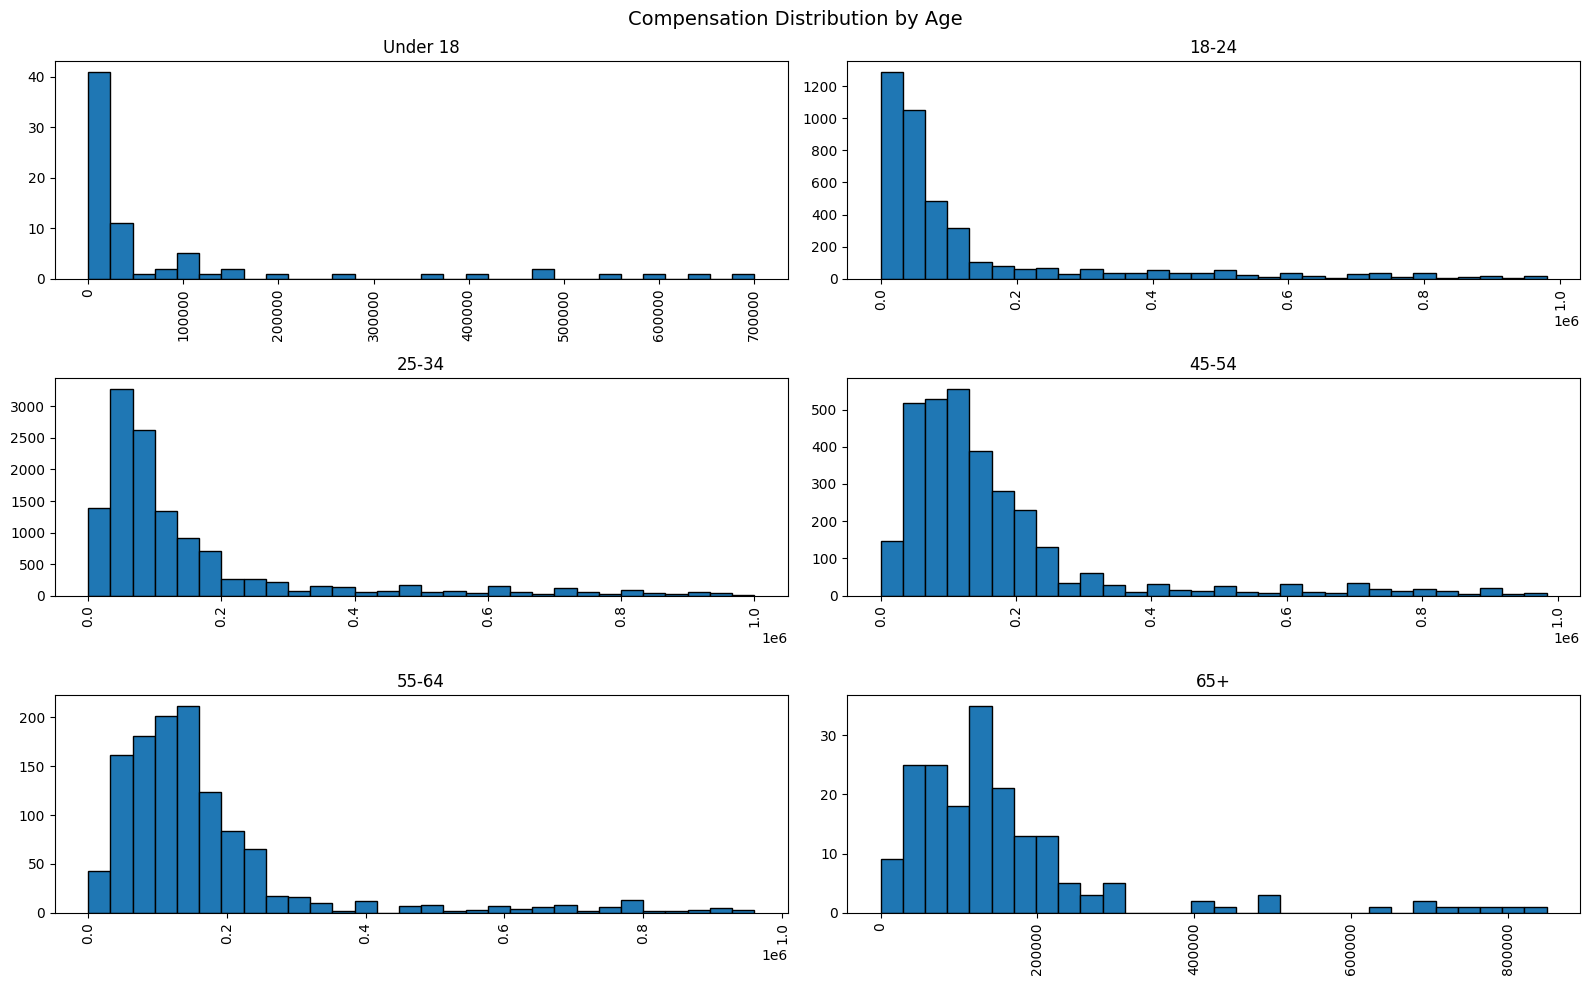

In [20]:
#change AGE to trimmed values and remove NAN
QUERY = """
SELECT
    CASE
        WHEN TRIM(Age) = 'Under 18 years old' THEN 'Under 18'
        WHEN TRIM(Age) = '18-24 years old' THEN '18-24'
        WHEN TRIM(Age) = '25-34 years old' THEN '25-34'
        WHEN TRIM(Age) = '35-44 years old' THEN '35-44'
        WHEN TRIM(Age) = '45-54 years old' THEN '45-54'
        WHEN TRIM(Age) = '55-64 years old' THEN '55-64'
        WHEN TRIM(Age) = '65 years or older' THEN '65+'
        ELSE NULL
    END AS Age_Clean,
    CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

df = pd.read_sql_query(QUERY, conn)


#Clean Age and outliers on CompTotal keeping reasonable values
df = df[df['Age_Clean'].notna()]

df = df[(df['CompTotal'] > 0) & (df['CompTotal'] < 1_000_000)]

#Ordering age groups
age_group = ['Under 18', '18-24', '25-34', '45-54', '55-64', '65+']
df['Age_Clean'] = pd.Categorical(df['Age_Clean'], categories=age_group, ordered=True)


#Hist plot
axes = df['CompTotal'].hist(
    by=df['Age_Clean'],
    bins=30,
    figsize=(16, 10),
    edgecolor='black')

plt.suptitle('Compensation Distribution by Age', fontsize=14)
plt.tight_layout()
plt.show()


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [21]:
## Write your code here
QUERY = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(TimeSearching) AS non_null,
    COUNT(*) - COUNT(TimeSearching) AS null_count,  
    MIN(TimeSearching) AS min_value,
    MAX (TimeSearching) AS max_value,
    AVG(TimeSearching) AS Avg_Value
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

   total_rows  non_null  null_count            min_value  \
0       65437     28911       36526  15-30 minutes a day   

                max_value  Avg_Value  
0  Over 120 minutes a day  26.360382  


In [22]:
QUERY = """
SELECT DISTINCT TimeSearching
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

                TimeSearching
0                         NaN
1         30-60 minutes a day
2        60-120 minutes a day
3         15-30 minutes a day
4  Less than 15 minutes a day
5      Over 120 minutes a day


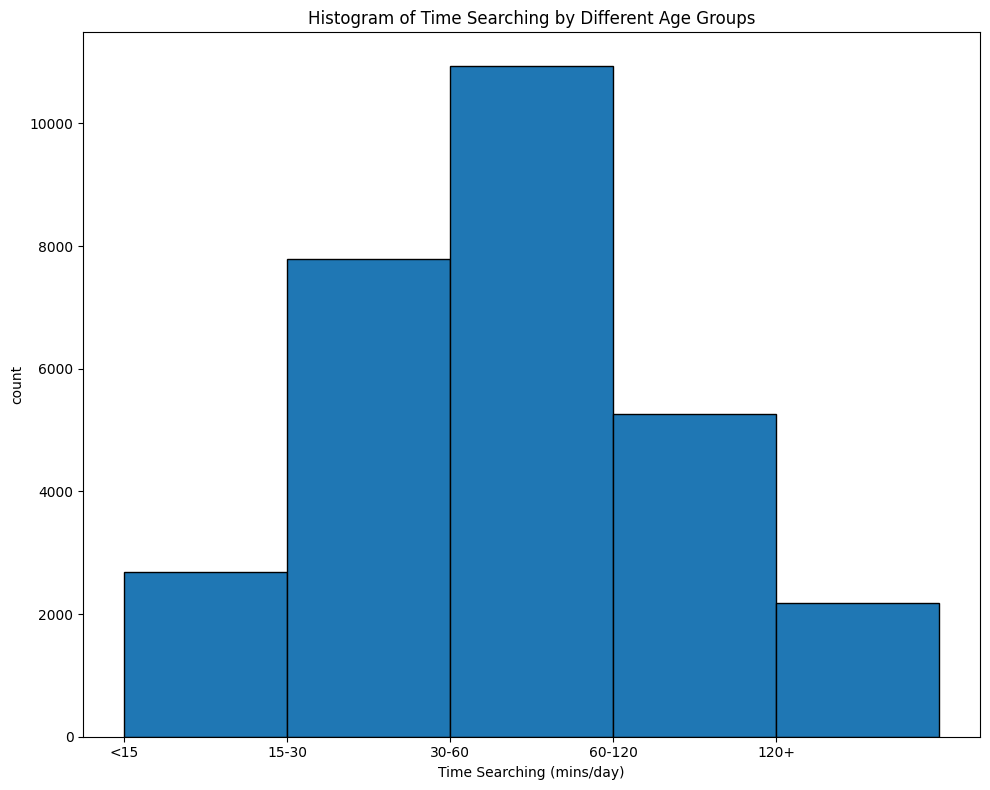

In [23]:
QUERY = """
SELECT
    CASE
        WHEN TRIM(Age) = 'Under 18 years old' THEN 'Under 18'
        WHEN TRIM(Age) = '18-24 years old' THEN '18-24'
        WHEN TRIM(Age) = '25-34 years old' THEN '25-34'
        WHEN TRIM(Age) = '35-44 years old' THEN '35-44'
        WHEN TRIM(Age) = '45-54 years old' THEN '45-54'
        WHEN TRIM(Age) = '55-64 years old' THEN '55-64'
        WHEN TRIM(Age) = '65 years or older' THEN '65+'
        ELSE NULL
    END AS Age_Clean,
    CASE
        WHEN TRIM(TimeSearching) = '15-30 minutes a day' THEN '15-30'
        WHEN TRIM(TimeSearching) = '30-60 minutes a day' THEN '30-60'
        WHEN TRIM(TimeSearching) = '60-120 minutes a day' THEN '60-120'
        WHEN TRIM(TimeSearching) = 'Less than 15 minutes a day' THEN '<15'
        WHEN TRIM(TimeSearching) = 'Over 120 minutes a day' THEN '120+'
        ELSE NULL
    END AS TimeSearching_C
FROM main
WHERE TimeSearching IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

Order = ['<15','15-30', '30-60', '60-120', '120+']
df['TimeSearching_C'] = pd.Categorical(df['TimeSearching_C'], categories=Order, ordered=True)

Age_Group = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Clean'] = pd.Categorical(df['Age_Clean'], categories=Age_Group, ordered=True)

#convert to numeric for Histogram
df = df.dropna(subset=['Age_Clean', 'TimeSearching_C']).copy()
df['Time_num'] = df['TimeSearching_C'].cat.codes

plt.figure(figsize=(10,8))

plt.hist(df['Time_num'], bins=range(len(Order) + 1), edgecolor='black')
plt.xticks(range(len(Order)), Order)

plt.title('Histogram of Time Searching by Different Age Groups')
plt.xlabel('Time Searching (mins/day)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [24]:
## Write your code here
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

#splitting and counting Top5 - 
QUERY = """
WITH RECURSIVE split_db AS(

    SELECT
        TRIM(
            CASE
            WHEN instr(DatabaseWantToWorkWith, ';') > 0
            THEN substr(DatabaseWantToWorkWith, 1, instr(DatabaseWantToWorkWith, ';') - 1)
                ELSE DatabaseWantToWorkWith
            END
        ) AS database,
        CASE
            WHEN instr(DatabaseWantToWorkWith, ';') > 0
            THEN substr(DatabaseWantToWorkWith, instr(DatabaseWantToWorkWith, ';') + 1)
            ELSE NULL
        END AS rest
    FROM main
    WHERE DatabaseWantToWorkWith IS NOT NULL

    UNION ALL

    SELECT
        TRIM(
            CASE
                WHEN instr(rest, ';') > 0
                THEN substr(rest, 1, instr(rest, ';') - 1)
                ELSE rest
            END),
            CASE
                WHEN instr(rest, ';') > 0
                THEN substr(rest, instr(rest, ';') +1)
                ELSE NULL
            END
        FROM split_db
        WHERE rest IS NOT NULL)

SELECT database, COUNT(*) AS COUNT
FROM split_db
WHERE database != ''
GROUP BY database
ORDER BY count DeSC
LIMIT 5;
"""
top5_df = pd.read_sql_query(QUERY, conn)
print(top5_df)
#above we have split the strings to make seperate rows and counted to get the top5

           DatabaseWantToWorkWith
0                             NaN
1                      PostgreSQL
2      Firebase Realtime Database
3        MongoDB;MySQL;PostgreSQL
4               PostgreSQL;SQLite
...                           ...
65432                         NaN
65433                         NaN
65434                         NaN
65435           PostgreSQL;SQLite
65436    MongoDB;MySQL;PostgreSQL

[65437 rows x 1 columns]
     database  COUNT
0  PostgreSQL  24005
1      SQLite  13489
2       MySQL  12269
3     MongoDB  10982
4       Redis  10847


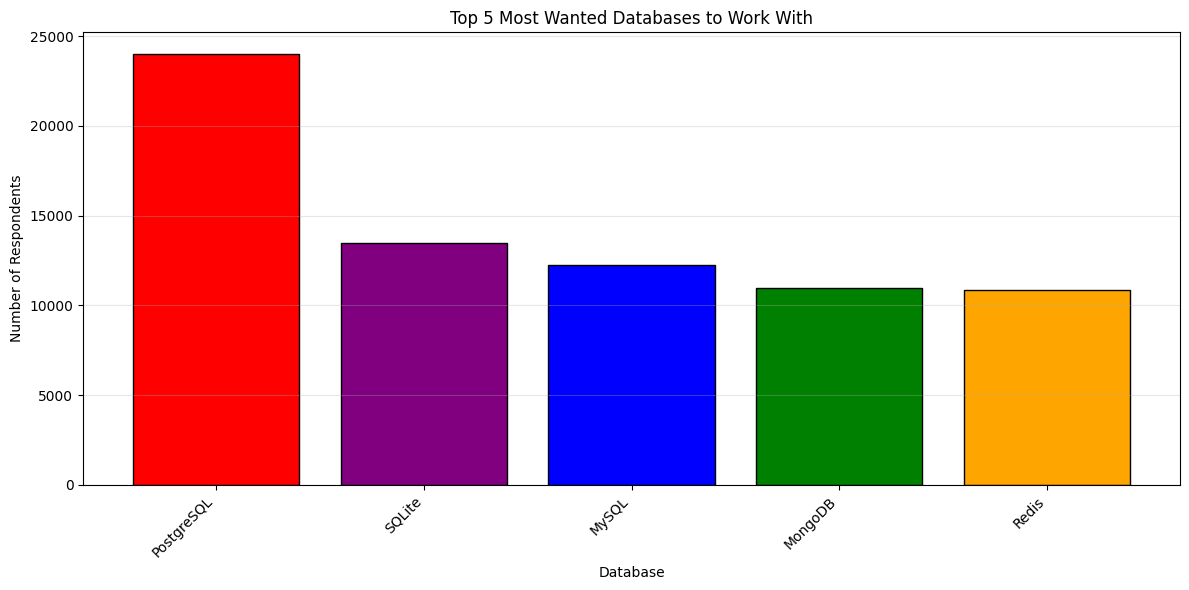

In [25]:
#plot the histogram showing the top 5 - Instead i have plotted a bar, due to the data being categorical and not continuous
colors = ['red', 'purple', 'blue', 'green', 'orange'] 

plt.figure(figsize=(12,6))
plt.bar(top5_df['database'], top5_df['COUNT'], color=colors,  edgecolor='black')
plt.title('Top 5 Most Wanted Databases to Work With')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [26]:
QUERY = """
SELECT  RemoteWork
FROM main
LIMIT 20
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

                              RemoteWork
0                                 Remote
1                                 Remote
2                                 Remote
3                                    NaN
4                                    NaN
5                                    NaN
6                                 Remote
7                                    NaN
8                              In-person
9                                 Remote
10                                Remote
11                             In-person
12  Hybrid (some remote, some in-person)
13                                   NaN
14  Hybrid (some remote, some in-person)
15  Hybrid (some remote, some in-person)
16                                   NaN
17                                Remote
18  Hybrid (some remote, some in-person)
19  Hybrid (some remote, some in-person)


                                 RemoteWork
0                                    Remote
1                                    Remote
2                                    Remote
3                                       NaN
4                                       NaN
...                                     ...
65432                                Remote
65433                                Remote
65434                             In-person
65435  Hybrid (some remote, some in-person)
65436                                   NaN

[65437 rows x 1 columns]


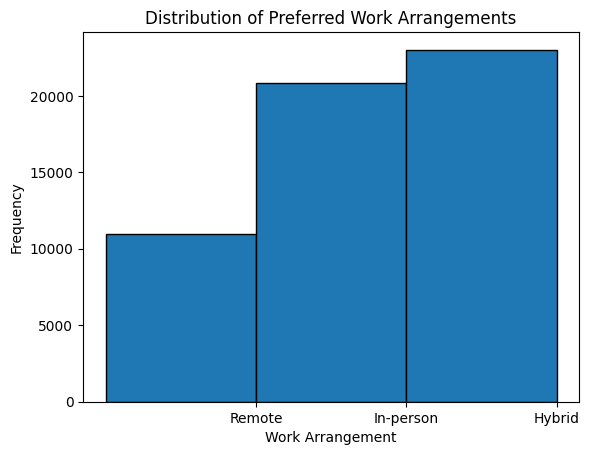

In [27]:
## Write your code here
QUERY = """
SELECT RemoteWork
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

QUERY = """
SELECT
    CASE
        WHEN TRIM(RemoteWork) IN ('Remote', 'RemoteWork') THEN 'Remote'
        WHEN TRIM(RemoteWork) = ' In-person' THEN ' In-person'
        WHEN TRIM(RemoteWork) = 'Hybrid (some remote, some in-person)' THEN 'Hybrid'
        ELSE NULL
    END AS work_clean
FROM main
WHERE RemoteWork IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

Work_sort = ['Remote', 'In-person', 'Hybrid']
df['work_clean'] = pd.Categorical(df['work_clean'], categories=Work_sort, ordered=True)

#convert to numreric
codes = df['work_clean'].cat.codes

plt.hist(codes, bins=3, edgecolor='black')
plt.xticks(ticks=[0, 1, 2], labels=Work_sort)
plt.title('Distribution of Preferred Work Arrangements')
plt.xlabel('Work Arrangement')
plt.ylabel('Frequency')
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


   total_rows  non_null  null_count  min_value      max_value      Avg_Value
0       65437     33740       31697        0.0  1.000000e+150  2.963841e+145


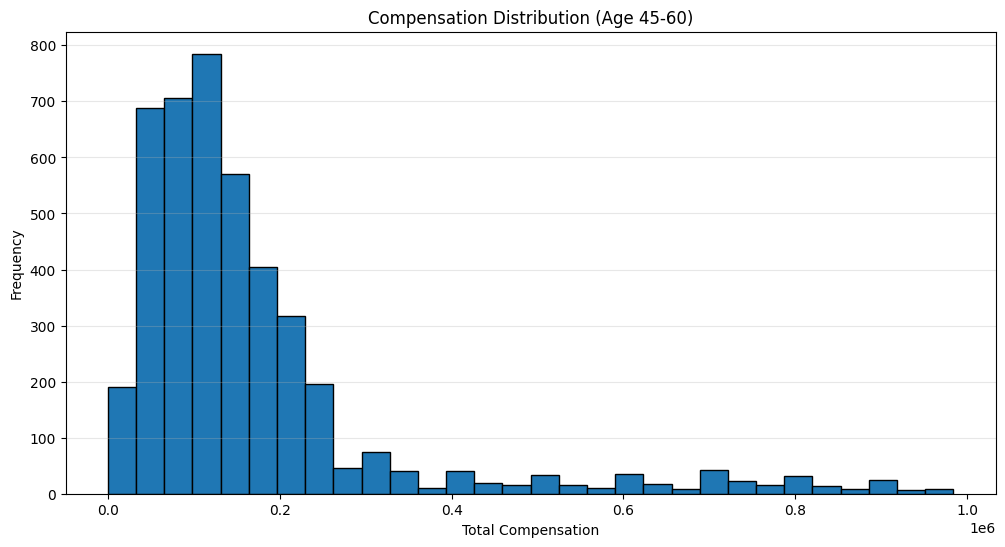

In [36]:
## Write your code here
QUERY = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(CompTotal) AS non_null,
    COUNT(*) - COUNT(CompTotal) AS null_count,  
    MIN(CompTotal) AS min_value,
    MAX (CompTotal) AS max_value,
    AVG(CompTotal) AS Avg_Value
FROM main
LIMIT 10
"""
df = pd.read_sql_query(QUERY, conn)
print(df)

QUERY = """
SELECT
    CASE
        WHEN TRIM(Age) = 'Under 18 years old' THEN 'Under 18'
        WHEN TRIM(Age) = '18-24 years old' THEN '18-24'
        WHEN TRIM(Age) = '25-34 years old' THEN '25-34'
        WHEN TRIM(Age) = '35-44 years old' THEN '35-44'
        WHEN TRIM(Age) = '45-54 years old' THEN '45-54'
        WHEN TRIM(Age) = '55-64 years old' THEN '55-64'
        WHEN TRIM(Age) = '65 years or older' THEN '65+'
     ELSE NULL
    END AS Age_Clean,
    CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

#Clean Age and outliers on CompTotal keeping reasonable values
df = df[df['Age_Clean'].notna()]

#filter to 45-60 group (using available)
df = df[df['Age_Clean'].isin(['45-54', '55-64'])] 

df = df[(df['CompTotal'] > 0) & (df['CompTotal'] < 1_000_000)]

#plot histogram
plt.figure(figsize=(12, 6))

plt.hist(df['CompTotal'], bins=30, edgecolor='black')

plt.title('Compensation Distribution (Age 45-60)')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [29]:
## Write your code here
QUERY = """
SELECT DISTINCT JobSat
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
print(df)
#shows a scale numeric (0->10)

    JobSat
0      NaN
1      8.0
2      5.0
3     10.0
4      6.0
5      9.0
6      4.0
7      7.0
8      3.0
9      2.0
10     1.0
11     0.0


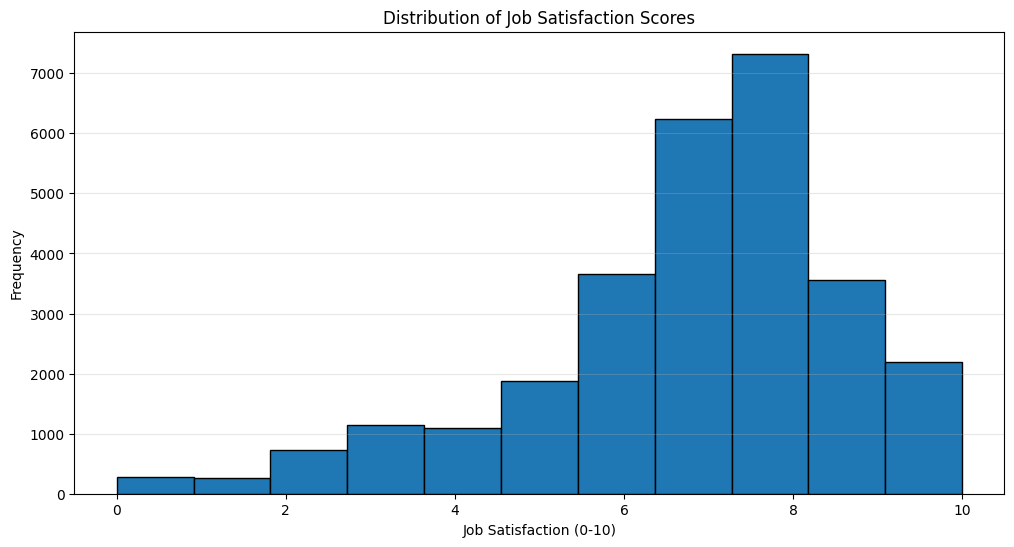

In [37]:
QUERY = """
SELECT 
    CASE
        WHEN YearsCodePro = 'more than 50 years' THEN 50
        WHEN YearsCodePro = 'less than 1 year' THEN 0
        ELSE CAST (YearsCodePro AS INT)
    END AS YearsCodePro_cleaned,
        
    JobSat
FROM main
WHERE JobSat IS NOT NULL
    AND YearsCodePro IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

df = df.dropna()

df = df[ 
    (df['YearsCodePro_cleaned'] >= 0) & 
    (df['YearsCodePro_cleaned'] <= 50)]

#Creating experience groups
bins = [0, 5, 10, 20, 30, 50]
labels = ['0-5', '6-10', '11-20', '21-30', '31+']
df['Experience_groups'] = pd.cut(df['YearsCodePro_cleaned'], bins=bins, labels=labels)

#plot the hisogram
plt.figure(figsize=(12, 6))

plt.hist(df['JobSat'], bins=11, edgecolor='black')

plt.title('Distribution of Job Satisfaction Scores')
plt.xlabel('Job Satisfaction (0-10)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [38]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
